The notebook contains examples on how to load spikes from .npy files. Loaded spikes are stored in .csv file (all units from all mice).

It plots some summary information about the dataset. The plot is saved in the figures google drive folder.

In [7]:
import numpy as np
import pandas as pd
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

#### Parameters

In [2]:
import os
print(os.getcwd())

/mnt/c/Users/Alina/Documents/ridetecives/pre-cosyne_brainhack_2026


In [3]:
# your path to the dataset
dataset_folder = Path('./brainhack-dataset/')

#### Helper functions

Includes two ways of loading the whole dataset (18 mice):
* store all units from all mice in .csv file. One row corresponds to one unit and has the following format: [mouse_id, cluster_id, brain_area, rec_len_sec, spikes]
* store all units from all mice in pandas dataframe (.pkl file). One row corresponds to one spike and has the following format (df columns): [spikes, brain_area, clusters, num_rec, len_rec]

#### store all units from all mice in .csv file.

In [4]:
def load_mouse_data(mouse_id: int, dataset_folder: Path, verbose: bool = True):
    """
    Load spikes, cluster IDs, and brain areas for a given mouse folder.

    Parameters
    ----------
    mouse_id : int
        Identifier of the mouse (folder name).
    dataset_folder : Path
        Root dataset folder.
    verbose : bool
        If True, print dataset shapes/info.

    Returns
    -------
    dict
        key is cluster_id, value is { 'spikes': [...], 'brain_area': int}
    """
    mouse_folder = dataset_folder / str(mouse_id)
    if verbose:
        print(f"Loading mouse {mouse_id} from {mouse_folder}")

    # file paths
    brain_areas_file = mouse_folder / "brain_area.npy"
    cluster_ids_file = mouse_folder / "clusters.npy"
    spikes_file = mouse_folder / "spikes.npy"

    # load arrays
    brain_areas = np.load(brain_areas_file, allow_pickle=True).item()
    cluster_ids = np.load(cluster_ids_file)
    spikes = np.load(spikes_file)

    if verbose:
        print(f"brain_areas keys: {list(brain_areas.keys())}")
        print(f"brain_area cluster_id shape: {brain_areas['cluster_id'].shape}")
        print(f"brain_area names shape: {brain_areas['brain_area'].shape}")
        print(f"cluster_ids shape: {cluster_ids.shape}, "
              f"unique clusters: {len(np.unique(cluster_ids))}")
        print(f"spikes shape: {spikes.shape}")

    # build brain area map
    brain_area_map = dict(zip(brain_areas["cluster_id"], brain_areas["brain_area"]))

    # organize spikes per cluster
    cluster_data = {}
    for cid, spike in zip(cluster_ids, spikes):
        cluster_data.setdefault(cid, {"spikes": [], "brain_area": brain_area_map[cid]})
        cluster_data[cid]["spikes"].append(spike)

    return cluster_data


def load_all_mice(dataset_folder: str | Path, n_mice: int = 18, verbose: bool = True):
    """
    Load spikes for all mice.

    Returns
    -------
    dict
        key is mouse_id (folder name), value is cluster_data
    """
    dataset_folder = Path(dataset_folder)
    all_data = {}
    for mouse_id in range(1, n_mice + 1):
        all_data[mouse_id] = load_mouse_data(mouse_id, dataset_folder, verbose=verbose)
    return all_data


def export_spikes_to_csv(spikes_dataset_dict: dict, dataset_folder: str | Path, filename: str = "output/full_dataset.csv") -> Path:
    """
    Export spikes dataset dict to a CSV file.

    Parameters
    ----------
    spikes_dataset_dict : dict
        key is mouse_id (folder name), value is cluster_data.
    dataset_folder : str | Path
        Root dataset folder where the CSV will be saved.
    filename : str, default="output/full_dataset.csv"
        Relative path of the CSV file inside dataset_folder.

    Returns
    -------
    Path
        Path to the created CSV file.
    """
    dataset_folder = Path(dataset_folder)
    csv_path = dataset_folder / filename
    csv_path.parent.mkdir(parents=True, exist_ok=True) 

    with open(csv_path, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["mouse_id", "cluster_id", "brain_area", "rec_len_sec", "spikes"])

        for mouse_id, clusters in spikes_dataset_dict.items():
            for cluster_id, data in clusters.items():
                spikes = data["spikes"]
                if not spikes:  # skip empty
                    continue
                rec_len_sec = spikes[-1]
                writer.writerow([
                    mouse_id,
                    cluster_id,
                    data["brain_area"],
                    rec_len_sec,
                    ";".join(map(str, spikes))
                ])

    print(f"CSV file '{csv_path}' has been created successfully!")
    return csv_path

#### store all units from all mice in pandas dataframe (.pkl file).

In [5]:
def get_spikes_area_clusters(num_rec, path_data=dataset_folder):
    spikes = np.load(path_data.joinpath(num_rec).joinpath('spikes.npy'))
    brainarea = np.load(path_data.joinpath(num_rec).joinpath('brain_area.npy'), allow_pickle=True)
    brainarea_d = brainarea.item()  # Convert numpy to dict
    clusters = np.load(path_data.joinpath(num_rec).joinpath('clusters.npy'), allow_pickle=True)
    return spikes, brainarea_d, clusters
    
def create_spike_table(spikes, brainarea_d, clusters):
    df = pd.DataFrame(columns=['spikes', 'brain_area', 'clusters'])
    df['spikes'] = spikes
    df['clusters'] = clusters
    mapping = dict(zip(brainarea_d["cluster_id"], brainarea_d["brain_area"]))
    df["brain_area"] = df["clusters"].map(mapping)
    return df
    
def create_df_1rec(num_rec, path_data=dataset_folder):
    spikes, brainarea_d, clusters = get_spikes_area_clusters(num_rec, path_data=path_data)
    df = create_spike_table(spikes, brainarea_d, clusters)
    df['num_rec'] = num_rec
    df['len_rec'] = spikes[-1] - spikes[0]
    return df
    
def get_spike_df(path_data=dataset_folder):
    for i_rec in range(1,19):  # RECORDING FROM 1-18
        df = create_df_1rec(str(i_rec), path_data=dataset_folder)
        if i_rec == 1:
            df_all = df.copy()
        else:
            df_all = pd.concat([df_all, df])  # Note this is a df with 44k rows

    return df_all

#### Loading spikes

In [31]:
# mouse_id=5
# spikes_dataset_dict = {
#     mouse_id: load_mouse_data(mouse_id, dataset_folder, False)
# }

# export_spikes_to_csv(spikes_dataset_dict, dataset_folder, "output/full_dataset.csv")

# spikes_df = create_df_1rec("2", path_data=dataset_folder)
# spikes_df.to_pickle(dataset_folder / "output/full_dataset.pkl")

In [32]:
spikes_dataset_dict = load_all_mice(dataset_folder, n_mice=18, verbose=False)
export_spikes_to_csv(spikes_dataset_dict, dataset_folder, "output/full_dataset.csv")

spikes_df = get_spike_df(path_data=dataset_folder)
spikes_df.to_pickle(dataset_folder / "output/full_dataset.pkl")

CSV file 'brainhack-dataset/output/full_dataset.csv' has been created successfully!


In [33]:
spikes_df

,spikes,brain_area,clusters,num_rec,len_rec
0,0.043605,1,445,1,3347.947894
1,0.047536,1,388,1,3347.947894
2,0.047569,1,389,1,3347.947894
3,0.048502,1,445,1,3347.947894
4,0.049168,2,713,1,3347.947894
...,...,...,...,...,...
1661739,4295.966527,1,647,18,4295.974485
1661740,4295.966860,1,336,18,4295.974485
1661741,4295.967894,2,560,18,4295.974485
1661742,4295.968227,1,306,18,4295.974485


#### Ploting summary info

total units count 1449


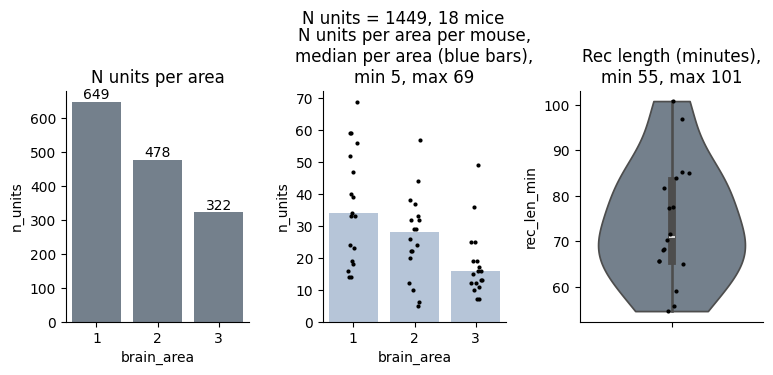

In [34]:
csv_filename = dataset_folder / "output/full_dataset.csv"
df = pd.read_csv(csv_filename, usecols=["mouse_id", "cluster_id", "brain_area", "rec_len_sec"])

# units per brain area
units_per_brain_area = (
    df.groupby("brain_area")["cluster_id"].count().reset_index(name="n_units")
)
mice_per_brain_area = (
    df.groupby("brain_area")["mouse_id"].nunique().reset_index(name="n_mice")
)
units_per_brain_area = pd.merge(units_per_brain_area, mice_per_brain_area, on="brain_area")
print(f"total units count {units_per_brain_area['n_units'].sum()}")

# units per area per mouse
units_per_brain_area_per_mouse = (
    df.groupby(["brain_area", "mouse_id"])["cluster_id"].count().reset_index(name="n_units")
)

# recording length per mouse 
rec_len_per_mouse = df.groupby("mouse_id")["rec_len_sec"].max().reset_index()
rec_len_per_mouse["rec_len_min"] = rec_len_per_mouse["rec_len_sec"] / 60

# plotting 
color = "slategrey"
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
plt.subplots_adjust(hspace=0.8, wspace=0.4)

# panel 0
sns.barplot(ax=axes[0], x="brain_area", y="n_units", data=units_per_brain_area, color=color)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f")
axes[0].set_title("N units per area")

# panel 1
sns.stripplot(ax=axes[1], x="brain_area", y="n_units", data=units_per_brain_area_per_mouse,
              color="black", s=3)
median_units = (
    units_per_brain_area_per_mouse.groupby("brain_area")["n_units"].median()
    .apply(np.ceil).astype(int).reset_index()
)
sns.barplot(ax=axes[1], x="brain_area", y="n_units", data=median_units, color="lightsteelblue")
axes[1].set_title(
    f"N units per area per mouse,\n"
    f"median per area (blue bars),\n"
    f"min {units_per_brain_area_per_mouse['n_units'].min()}, "
    f"max {units_per_brain_area_per_mouse['n_units'].max()}"
)

# panel 2
sns.violinplot(ax=axes[2], y="rec_len_min", data=rec_len_per_mouse,
               cut=0, density_norm="width", color=color)
sns.stripplot(ax=axes[2], y="rec_len_min", data=rec_len_per_mouse, color="black", s=3)
axes[2].set_title(
    f"Rec length (minutes),\n"
    f"min {rec_len_per_mouse['rec_len_min'].min():.0f}, "
    f"max {rec_len_per_mouse['rec_len_min'].max():.0f}"
)

fig.suptitle(
    f"N units = {units_per_brain_area['n_units'].sum()}, "
    f"{df['mouse_id'].nunique()} mice", y=1.15
)
sns.despine()
fig.savefig(dataset_folder / "output/spikes_info.png", bbox_inches="tight")

In [35]:
# collect all trial_data.csv into one DataFrame
all_trials = []
for ii in range(1, 19):
    trialdata_filename = dataset_folder / str(ii) / "trial_data.csv"
    df_mouse = pd.read_csv(trialdata_filename).drop(columns="Unnamed: 0", errors="ignore")
    df_mouse["trial_duration"] = df_mouse["trial_end"] - df_mouse["trial_start"]
    df_mouse.insert(0, "mouse_id", ii)   # put mouse_id as the first column
    all_trials.append(df_mouse)

trials_df = pd.concat(all_trials, ignore_index=True)
trials_df.to_csv(dataset_folder / 'output/trials_info.csv')

trials_df

,mouse_id,variable_A,variable_B,variable_C,trial_start,stim_start,outcome,trial_end,trial_duration
0,1,1,1,2,58.738992,69.705862,69.962403,71.072492,12.333500
1,1,1,1,2,72.098523,74.872945,75.279471,76.388860,4.290338
2,1,1,1,2,77.404392,79.222444,79.406092,80.505349,3.100957
3,1,0,0,2,81.501916,83.989167,84.185347,86.287937,4.786021
4,1,1,1,2,87.272272,88.888844,89.161016,90.271139,2.998867
...,...,...,...,...,...,...,...,...,...
10368,18,0,1,0,2715.423097,2716.084831,2720.247848,2722.301243,6.878146
10369,18,0,1,0,2723.725034,2724.191687,2731.254981,2733.301043,9.576009
10370,18,0,1,0,2734.733566,2735.207785,2735.684571,2737.733933,3.000367
10371,18,0,1,0,2739.147558,2739.891417,2740.525853,2742.584147,3.436589


In [36]:
# # collect all trial_data.csv into one DataFrame
# all_trials = []

# trialdata_filename = dataset_folder / str(mouse_id) / "trial_data.csv"
# df_mouse = pd.read_csv(trialdata_filename).drop(columns="Unnamed: 0", errors="ignore")
# df_mouse["trial_duration"] = df_mouse["trial_end"] - df_mouse["trial_start"]
# df_mouse.insert(0, "mouse_id", mouse_id)   # put mouse_id as the first column
# all_trials.append(df_mouse)

# trials_df = pd.concat(all_trials, ignore_index=True)
# trials_df.to_csv(dataset_folder / 'output/trials_info.csv')

# trials_df

In [37]:
trials_df["variable_C"].unique()

array([2, 0, 1])

### Separate the spikes in three df

In [41]:
# pre_spikes = []
# stim_spikes = []
# post_spikes = []

# for i, trial in trials_df.iterrows():
#     t_start = trial["trial_start"]
#     t_stim = trial["stim_start"]
#     t_outcome = trial["outcome"]
#     t_end = trial["trial_end"]

#     df_pre = spikes_df[
#         (spikes_df["spikes"] >= t_start) & (spikes_df["spikes"] < t_stim)
#     ].copy()
#     df_pre["trial"] = i
#     df_pre["segment"] = "pre"
#     pre_spikes.append(df_pre)

#     df_stim = spikes_df[
#         (spikes_df["spikes"] >= t_stim) & (spikes_df["spikes"] < t_outcome)
#     ].copy()
#     df_stim["trial"] = i
#     df_stim["segment"] = "stim"
#     stim_spikes.append(df_stim)

#     df_post = spikes_df[
#         (spikes_df["spikes"] >= t_outcome) & (spikes_df["spikes"] < t_end)
#     ].copy()
#     df_post["trial"] = i
#     df_post["segment"] = "post"
#     post_spikes.append(df_post)

In [42]:
# pre_df = pd.concat(pre_spikes, ignore_index=True)
# stim_df = pd.concat(stim_spikes, ignore_index=True)
# post_df = pd.concat(post_spikes, ignore_index=True)

In [43]:
# print(pre_df[["trial", "segment"]].isna().sum())
# print(stim_df[["trial", "segment"]].isna().sum())
# print(post_df[["trial", "segment"]].isna().sum())

In [44]:
# pre_df

In [45]:
# stim_df

In [46]:
# post_df

In [47]:
trials_df = trials_df.copy()
trials_df["trial"] = trials_df.groupby("mouse_id").cumcount()

In [54]:
def assign_spikes_to_trials(spikes_df, trials_df):
    spikes_df = spikes_df.copy()
    trials_df = trials_df.copy()

    # make the recording key explicit and consistent
    spikes_df["num_rec"] = pd.to_numeric(spikes_df["num_rec"], errors="coerce").astype("Int64")
    trials_df["mouse_id"] = pd.to_numeric(trials_df["mouse_id"], errors="coerce").astype("Int64")

    # make sure time columns are numeric
    spike_time_col = "spikes"
    trial_time_cols = ["trial_start", "stim_start", "outcome", "trial_end"]
    spikes_df[spike_time_col] = pd.to_numeric(spikes_df[spike_time_col], errors="coerce")
    for col in trial_time_cols:
        trials_df[col] = pd.to_numeric(trials_df[col], errors="coerce")

    # drop broken rows
    spikes_df = spikes_df.dropna(subset=["num_rec", spike_time_col]).copy()
    trials_df = trials_df.dropna(subset=["mouse_id"] + trial_time_cols).copy()

    # ensure integer ids
    spikes_df["num_rec"] = spikes_df["num_rec"].astype(int)
    trials_df["mouse_id"] = trials_df["mouse_id"].astype(int)

    # create per-mouse trial index if missing
    if "trial" not in trials_df.columns:
        trials_df = trials_df.sort_values(["mouse_id", "trial_start"]).copy()
        trials_df["trial"] = trials_df.groupby("mouse_id").cumcount()

    assigned = []

    for mouse_id, trials_mouse in trials_df.groupby("mouse_id", sort=True):
        spikes_mouse = spikes_df.loc[spikes_df["num_rec"] == mouse_id].copy()

        if spikes_mouse.empty:
            continue

        for _, trial_row in trials_mouse.iterrows():
            t_start = float(trial_row["trial_start"])
            t_stim = float(trial_row["stim_start"])
            t_outcome = float(trial_row["outcome"])
            t_end = float(trial_row["trial_end"])

            # skip malformed trials
            if not (t_start <= t_stim <= t_outcome <= t_end):
                continue

            mask = (spikes_mouse[spike_time_col] >= t_start) & (spikes_mouse[spike_time_col] < t_end)
            df_trial = spikes_mouse.loc[mask].copy()

            if df_trial.empty:
                continue

            df_trial["mouse_id"] = mouse_id
            df_trial["trial"] = int(trial_row["trial"])
            df_trial["variable_C"] = trial_row["variable_C"]

            df_trial["aligned_to_start"] = df_trial[spike_time_col] - t_start
            df_trial["aligned_to_stim"] = df_trial[spike_time_col] - t_stim
            df_trial["aligned_to_outcome"] = df_trial[spike_time_col] - t_outcome

            df_trial["segment"] = pd.cut(
                df_trial[spike_time_col],
                bins=[t_start, t_stim, t_outcome, t_end],
                labels=["pre", "stim", "post"],
                right=False,
                include_lowest=True,
            )

            assigned.append(df_trial)

    if not assigned:
        raise ValueError(
            "No spikes were assigned to any trial. "
            "Check that trials_df['mouse_id'] matches spikes_df['num_rec'] "
            "and that spike times overlap the trial intervals within each mouse."
        )

    spikes_trials_df = pd.concat(assigned, ignore_index=True)
    return spikes_trials_df

In [55]:
spikes_trials_df = assign_spikes_to_trials(spikes_df, trials_df)

In [57]:
spikes_trials_df.head()

,spikes,brain_area,clusters,num_rec,len_rec,mouse_id,trial,variable_C,aligned_to_start,aligned_to_stim,aligned_to_outcome,segment
0,58.741569,1,386,1,3347.947894,1,0,2.0,0.002577,-10.964293,-11.220834,pre
1,58.742136,1,445,1,3347.947894,1,0,2.0,0.003144,-10.963726,-11.220267,pre
2,58.745134,2,733,1,3347.947894,1,0,2.0,0.006142,-10.960728,-11.217269,pre
3,58.745867,1,865,1,3347.947894,1,0,2.0,0.006875,-10.959995,-11.216536,pre
4,58.749531,1,445,1,3347.947894,1,0,2.0,0.010539,-10.956331,-11.212872,pre


In [58]:
spikes_trials_df[["mouse_id", "trial", "aligned_to_stim", "segment"]].head()

,mouse_id,trial,aligned_to_stim,segment
0,1,0,-10.964293,pre
1,1,0,-10.963726,pre
2,1,0,-10.960728,pre
3,1,0,-10.959995,pre
4,1,0,-10.956331,pre


In [59]:
spikes_trials_df.shape

(25815150, 12)

### Compute neural population vectors

Trial-wise spike counts per neuron

In [60]:
def compute_sliding_window_population(
    spikes_trials_df,
    trials_df,
    align_col="aligned_to_stim",
    label_col="variable_C",
    window_size=0.2,
    step_size=0.05,
    t_min=-2.0,
    t_max=2.0,
):
    trial_keys = (
        trials_df[["mouse_id", "trial", label_col]]
        .drop_duplicates()
        .sort_values(["mouse_id", "trial"])
        .reset_index(drop=True)
    )

    neurons = np.array(sorted(spikes_trials_df["clusters"].unique()))

    window_starts = np.arange(t_min, t_max - window_size + step_size, step_size)
    window_centers = window_starts + window_size / 2

    X_by_window = {}

    for w_start, w_center in zip(window_starts, window_centers):
        w_end = w_start + window_size

        dfw = spikes_trials_df[
            (spikes_trials_df[align_col] >= w_start) &
            (spikes_trials_df[align_col] < w_end)
        ]

        Xw = (
            dfw.groupby(["mouse_id", "trial", "clusters"])
            .size()
            .unstack(fill_value=0)
        )

        full_index = pd.MultiIndex.from_frame(trial_keys[["mouse_id", "trial"]])

        Xw = Xw.reindex(index=full_index, columns=neurons, fill_value=0)
        Xw.index = trial_keys.index  # easier row indexing later

        X_by_window[float(w_center)] = Xw

    y = trial_keys[label_col].to_numpy()

    return X_by_window, y, window_centers, trial_keys

In [73]:
X_by_window, y, window_centers, trial_keys = compute_sliding_window_population(
    spikes_trials_df=spikes_trials_df,
    trials_df=trials_df,
    align_col="aligned_to_stim",
    label_col="variable_C",
    window_size=0.3,
    step_size=0.2,
    t_min=-1.5,
    t_max=1.5,
)

# non overlapping windows
# window_size=0.2,
# step_size=0.2,

In [87]:
trial_keys["variable_C"].unique()

array([2, 0, 1])

In [74]:
# neurons = np.array(sorted(spikes_trials_df["clusters"].unique()))
# neurons

In [89]:
print(np.unique(y))
print(pd.Series(y).value_counts().sort_index())

[0 1 2]
0    5040
1      29
2    5304
Name: count, dtype: int64


In [91]:
trials_df["variable_C"].value_counts()

variable_C
2    5304
0    5040
1      29
Name: count, dtype: int64

### Z-scoring

After z-scoring: all neurons contribute on comparable scale, which improves decoding stability.

In [88]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# pre_z  = scaler.fit_transform(pre_pop)
# stim_z = scaler.fit_transform(stim_pop)
# post_z = scaler.fit_transform(post_pop)

### Model

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# -----------------------------------
# 1) Keep only classes 0 and 2
# -----------------------------------
valid_mask = (y != 1)
y_bin = y[valid_mask]

print("Original classes:")
print(pd.Series(y).value_counts().sort_index())
print("\nFiltered classes:")
print(pd.Series(y_bin).value_counts().sort_index())

# -----------------------------------
# 2) Model
# -----------------------------------
clf = make_pipeline(
    StandardScaler(),
    LinearSVC(max_iter=10000)
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# keep only every 4th window for speed
all_times = np.array(sorted(X_by_window.keys()))
times = all_times[::4]
n_windows = len(times)

scores = []

start_time = time.time()

print("\nStarting sliding-window decoding")
print(f"Total windows: {n_windows}")
print("")

for i, t in enumerate(times):
    window_start = time.time()

    Xw = X_by_window[t]

    # apply the same trial filter to each window matrix
    if isinstance(Xw, pd.DataFrame):
        Xw_bin = Xw.loc[valid_mask]
    else:
        Xw_bin = Xw[valid_mask]

    print(f"[{i+1}/{n_windows}] Window centered at {t:.3f} s", end=" ")

    s = cross_val_score(
        clf,
        Xw_bin,
        y_bin,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    scores.append(s)

    window_time = time.time() - window_start
    elapsed = time.time() - start_time
    remaining = (elapsed / (i + 1)) * (n_windows - i - 1)

    print(f"| score={s:.4f} | window_time={window_time:.2f}s | ETA={remaining/60:.1f} min")

scores = np.array(scores)

total_time = time.time() - start_time

print("")
print("Decoding finished")
print(f"Total runtime: {total_time/60:.2f} minutes")

best_idx = np.argmax(scores)

print("")
print("Best decoding:")
print(f"time = {times[best_idx]:.3f} s")
print(f"score = {scores[best_idx]:.4f}")
print(f"binary balanced-chance = {0.5:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(times, scores, marker="o")
plt.axhline(0.5, linestyle="--", label="chance")
plt.axvline(0, linestyle="--", label="stim_start")
plt.xlabel("Time from stim_start (s)")
plt.ylabel("Balanced accuracy")
plt.title("Decoding of variable_C over time (classes 0 vs 2)")
plt.legend()
plt.show()

Original classes:
0    5040
1      29
2    5304
Name: count, dtype: int64

Filtered classes:
0    5040
2    5304
Name: count, dtype: int64

Starting sliding-window decoding
Total windows: 4

[1/4] Window centered at -1.350 s 

In [79]:
stim_duration = (trials_df["outcome"] - trials_df["stim_start"]).median()
print("stim duration:", stim_duration)

stim duration: 0.3825590999999804


In [80]:
pre_mask = times < 0
stim_mask = (times >= 0) & (times < stim_duration)
post_mask = times >= stim_duration

In [81]:
acc_pre = scores[pre_mask].mean()
acc_stim = scores[stim_mask].mean()
acc_post = scores[post_mask].mean()

print("Pre accuracy :", acc_pre)
print("Stim accuracy:", acc_stim)
print("Post accuracy:", acc_post)

Pre accuracy : 0.3637331713312105
Stim accuracy: 0.48533302209772805
Post accuracy: 0.4697262523242915


In [82]:
segment_scores = {
    "pre": acc_pre,
    "stim": acc_stim,
    "post": acc_post
}

print("Best segment:", max(segment_scores, key=segment_scores.get))

Best segment: stim


In [ ]:
stim_duration = (trials_df["outcome"] - trials_df["stim_start"]).median()

pre_mask = times < 0
stim_mask = (times >= 0) & (times < stim_duration)
post_mask = times >= stim_duration

acc_pre = scores[pre_mask].mean() if np.any(pre_mask) else np.nan
acc_stim = scores[stim_mask].mean() if np.any(stim_mask) else np.nan
acc_post = scores[post_mask].mean() if np.any(post_mask) else np.nan

segment_names = ["pre", "stim", "post"]
segment_values = [acc_pre, acc_stim, acc_post]

print("\nSegment accuracies:")
for name, val in zip(segment_names, segment_values):
    print(f"{name}: {val:.4f}")

print("Best segment:", segment_names[np.nanargmax(segment_values)])

plt.figure(figsize=(6, 4))
plt.bar(segment_names, segment_values)
plt.axhline(0.5, linestyle="--", label="chance")
plt.ylabel("Balanced accuracy")
plt.title("Decoding accuracy per trial segment (classes 0 vs 2)")
plt.legend()
plt.show()